In [ ]:
import pandas as pd

# Load datasets
employees = pd.read_csv("employees.csv", parse_dates=["hire_date", "exit_date"])
attrition = pd.read_csv("attrition_log.csv", parse_dates=["exit_date"])
engagement = pd.read_csv("engagement.csv", parse_dates=["survey_date"])
performance = pd.read_csv("performance.csv", parse_dates=["review_date"])

# Rename attrition exit_date so it does not clash with employees.exit_date.
attrition_detail = attrition.rename(columns={"exit_date": "attrition_exit_date"})

# Employee-level combined dataset: one row per employee.
# Use this for headcount, department, leaver, salary, and hire-source analysis.
df = employees.merge(
    attrition_detail,
    on="employee_id",
    how="left"
)

# Fully expanded activity dataset for later engagement/performance analysis.
# This has multiple rows per employee because surveys and reviews repeat over time.
combined_activity = (
    df.merge(engagement, on="employee_id", how="left")
      .merge(performance, on="employee_id", how="left")
)

# One row per person who left, joined back to employee fields needed for analysis.
leavers = attrition_detail.merge(
    employees[["employee_id", "department", "hire_source", "salary", "status"]],
    on="employee_id",
    how="left"
)

pd.set_option("display.max_columns", None)

print("Employee-level combined shape:", df.shape)
print("Expanded activity shape:", combined_activity.shape)
print("Leavers:", leavers["employee_id"].nunique())

df.head()



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# PART 1 - EMPLOYEE POPULATION PROFILE

print("EMPLOYEE POPULATION")
print("=" * 60)

print(f"Total employees: {df['employee_id'].nunique():,}")
print(f"Active employees: {(df['status'] == 'active').sum():,}")
print(f"Departed employees: {(df['status'] == 'departed').sum():,}")
print(f"Departments: {df['department'].nunique()}")
print(f"Role families: {df['role_family'].nunique()}")
print(f"Job titles: {df['job_title'].nunique()}")

# Department size
department_size = (
    df["department"]
    .value_counts()
    .rename_axis("department")
    .reset_index(name="employees")
)

department_size["percentage"] = (
    department_size["employees"]
    / df["employee_id"].nunique() * 100
)

display(department_size)

# Role family size
role_family_size = (
    df["role_family"]
    .value_counts()
    .rename_axis("role_family")
    .reset_index(name="employees")
)

role_family_size["percentage"] = (
    role_family_size["employees"]
    / df["employee_id"].nunique() * 100
)

display(role_family_size)



In [ ]:
# 2. DEPARTMENT COMPOSITION

department_composition = pd.crosstab(
    df["department"],
    df["role_family"],
    normalize="index"
) * 100

display(department_composition.round(1))

department_composition.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Role-family composition of each department")
plt.xlabel("Department")
plt.ylabel("Percentage of employees")
plt.legend(
    title="Role family",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
department_analysis = (
    df.groupby("department")
      .agg(
          employees=("employee_id", "nunique"),
          leavers=("exit_type", lambda x: x.notna().sum()),
          median_salary=("salary", "median"),
          mean_salary=("salary", "mean")
      )
)

department_analysis["attrition_rate"] = (
    department_analysis["leavers"]
    / department_analysis["employees"]
    * 100
)

department_analysis = department_analysis.sort_values(
    "attrition_rate",
    ascending=False
)

display(department_analysis.round(2))

In [ ]:
# Merge employee fields onto attrition records.
# attrition_log.csv has the employee_id and exit details.
# employees.csv has department and hire_source.
leavers = attrition.merge(
    employees[["employee_id", "department", "hire_source"]],
    on="employee_id",
    how="left"
)

display(leavers.head())



In [ ]:

# 4. LEAVERS BY DEPARTMENT + EXIT SALARY

leavers_by_department = (
    leavers.groupby("department")
    .agg(
        leavers=("employee_id", "nunique"),
        median_exit_salary=("salary_at_exit", "median"),
        mean_exit_salary=("salary_at_exit", "mean")
    )
    .sort_values("leavers", ascending=False)
    .reset_index()
)

display(leavers_by_department.round(2))

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=leavers_by_department,
    x="department",
    y="leavers",
    ax=ax1,
    color="#4C78A8",
    label="Leavers"
)

ax1.set_title("Leavers by Department and Median Exit Salary")
ax1.set_xlabel("Department")
ax1.set_ylabel("Number of leavers")
ax1.tick_params(axis="x", rotation=35)

ax2 = ax1.twinx()
ax2.plot(
    leavers_by_department["department"],
    leavers_by_department["median_exit_salary"],
    color="#F58518",
    marker="o",
    linewidth=2.5,
    label="Median exit salary"
)
ax2.set_ylabel("Median salary at exit")
ax2.yaxis.set_major_formatter(lambda x, _: f"${x:,.0f}")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()



First 20 leavers matched back to their hire source:


,employee_id,hire_source,department,exit_type,salary_at_exit
0,E00008,acquisition,Technology,voluntary,117800.0
1,E00483,acquisition,Retail Banking,voluntary,129300.0
2,E00573,acquisition,Insurance,voluntary,118500.0
3,E00669,acquisition,Risk & Compliance,voluntary,121700.0
4,E00834,acquisition,Retail Banking,voluntary,180900.0
5,E00915,acquisition,Retail Banking,involuntary,125700.0
6,E00923,acquisition,Technology,voluntary,140200.0
7,E01302,acquisition,Retail Banking,voluntary,131300.0
8,E01719,acquisition,Retail Banking,voluntary,130700.0
9,E01809,acquisition,Retail Banking,voluntary,124200.0


,hire_source,total_employees,leavers,attrition_rate
3,graduate,683,94,13.76
0,acquisition,5344,581,10.87
2,direct,2787,276,9.90
1,agency,3243,318,9.81
4,referral,1346,131,9.73


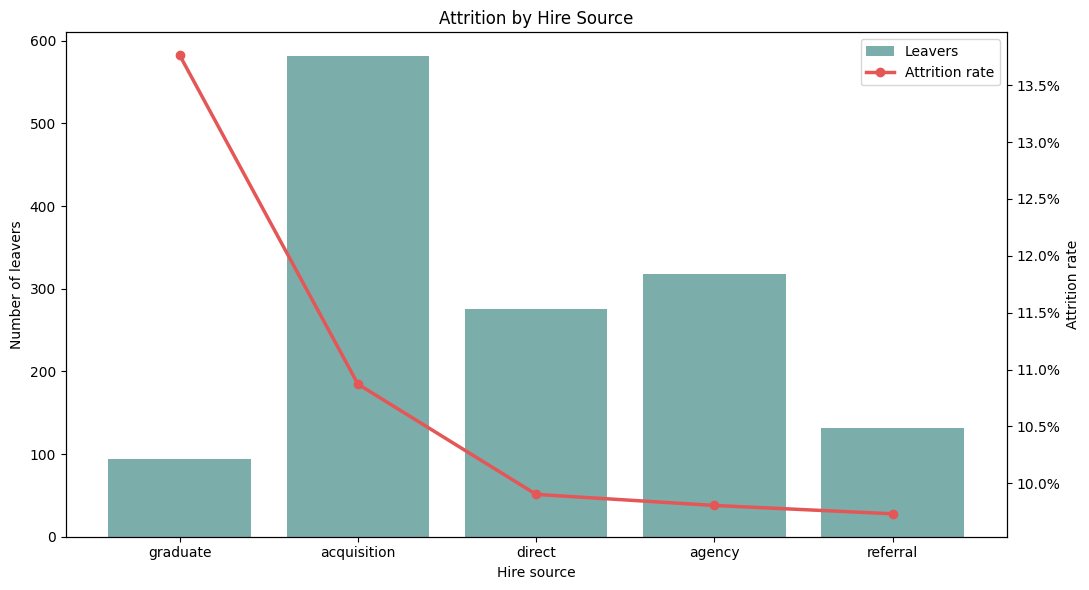

Overall attrition rate: 10.45%


,hire_source,total_employees,leavers,attrition_rate,vs_overall_pct_points
3,graduate,683,94,13.76,3.32
0,acquisition,5344,581,10.87,0.43
2,direct,2787,276,9.90,-0.54
1,agency,3243,318,9.81,-0.64
4,referral,1346,131,9.73,-0.71


In [ ]:
# 5. ATTRITION BY HIRE SOURCE

# Build directly from attrition + employees so hire_source is definitely present.
attrition_hire_source_detail = (
    attrition.merge(
        employees[["employee_id", "hire_source", "department"]],
        on="employee_id",
        how="left"
    )[["employee_id", "hire_source", "department", "exit_type", "salary_at_exit"]]
    .sort_values(["hire_source", "employee_id"])
    .reset_index(drop=True)
)

print("First 20 leavers matched back to their hire source:")
display(attrition_hire_source_detail.head(20))

hire_source_summary = (
    employees.groupby("hire_source")
    .agg(total_employees=("employee_id", "nunique"))
    .join(
        attrition_hire_source_detail.groupby("hire_source")
        .agg(leavers=("employee_id", "nunique")),
        how="left"
    )
    .fillna({"leavers": 0})
    .reset_index()
)

hire_source_summary["leavers"] = hire_source_summary["leavers"].astype(int)
hire_source_summary["attrition_rate"] = (
    hire_source_summary["leavers"]
    / hire_source_summary["total_employees"]
    * 100
)

hire_source_summary = hire_source_summary.sort_values("attrition_rate", ascending=False)

display(hire_source_summary.round(2))

fig, ax1 = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=hire_source_summary,
    x="hire_source",
    y="leavers",
    ax=ax1,
    color="#72B7B2",
    label="Leavers"
)

ax1.set_title("Attrition by Hire Source")
ax1.set_xlabel("Hire source")
ax1.set_ylabel("Number of leavers")

ax2 = ax1.twinx()
ax2.plot(
    hire_source_summary["hire_source"],
    hire_source_summary["attrition_rate"],
    color="#E45756",
    marker="o",
    linewidth=2.5,
    label="Attrition rate"
)
ax2.set_ylabel("Attrition rate")
ax2.yaxis.set_major_formatter(lambda x, _: f"{x:.1f}%")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

# Quick read on whether hire source looks related to attrition.
overall_attrition_rate = (
    attrition_hire_source_detail["employee_id"].nunique()
    / employees["employee_id"].nunique()
    * 100
)

hire_source_summary["vs_overall_pct_points"] = (
    hire_source_summary["attrition_rate"] - overall_attrition_rate
)

print(f"Overall attrition rate: {overall_attrition_rate:.2f}%")
display(
    hire_source_summary[
        ["hire_source", "total_employees", "leavers", "attrition_rate", "vs_overall_pct_points"]
    ].round(2)
)




## Engagement and attrition direction

The case brief points to a People Reinvention problem: NovaCorp wants voluntary attrition below 9.5%, with Risk & Compliance, Corporate Operations, and Entity_B integration risk called out. The engagement data helps explain the employee experience behind the leaver patterns already shown above.

To avoid leakage, this section uses each departed employee's last completed survey before their exit date. Active employees use their latest completed survey in the engagement file.


In [ ]:
# ------------------------------------------------------------
# 6. ENGAGEMENT SNAPSHOT BEFORE ATTRITION
# ------------------------------------------------------------

engagement_vars = [
    "manager_effectiveness",
    "psychological_safety",
    "recognition",
    "career_development",
    "senior_leadership_trust",
    "purpose_meaning",
    "wellbeing",
    "confidence_in_role_future",
]

# Use only completed survey responses with all engagement factor scores present.
engagement_completed = engagement[
    engagement["response_flag"]
    & engagement[engagement_vars].notna().all(axis=1)
].copy()

employee_context = employees[
    [
        "employee_id",
        "status",
        "department",
        "role_level",
        "role_family",
        "legacy_entity_code",
        "hire_source",
        "exit_date",
    ]
].merge(
    attrition[["employee_id", "exit_type", "stated_exit_reason"]],
    on="employee_id",
    how="left",
)

engagement_candidates = engagement_completed.merge(
    employee_context,
    on="employee_id",
    how="inner",
)

# For leavers, keep surveys before exit. For active employees, use the latest survey available.
latest_survey_date = engagement["survey_date"].max()
engagement_candidates["snapshot_cutoff"] = engagement_candidates["exit_date"].fillna(latest_survey_date)
engagement_candidates = engagement_candidates[
    engagement_candidates["survey_date"] <= engagement_candidates["snapshot_cutoff"]
].copy()

engagement_snapshot = (
    engagement_candidates
    .sort_values(["employee_id", "survey_date", "wave_number"])
    .groupby("employee_id")
    .tail(1)
    .copy()
)

engagement_snapshot["attrited"] = engagement_snapshot["status"].eq("departed")
engagement_snapshot["voluntary_attrited"] = engagement_snapshot["exit_type"].eq("voluntary")
engagement_snapshot["overall_engagement"] = engagement_snapshot[engagement_vars].mean(axis=1)

# Focus driver analysis on voluntary leavers vs active employees.
# Involuntary leavers are excluded because survey sentiment is less likely to explain that exit type.
voluntary_engagement_snapshot = engagement_snapshot[
    engagement_snapshot["exit_type"].isna()
    | engagement_snapshot["exit_type"].eq("voluntary")
].copy()

engagement_snapshot_coverage = pd.DataFrame({
    "metric": [
        "Employees in employees.csv",
        "Employees with usable engagement snapshot",
        "Active employees with snapshot",
        "All leavers with pre-exit snapshot",
        "Voluntary leavers with pre-exit snapshot",
    ],
    "count": [
        employees["employee_id"].nunique(),
        engagement_snapshot["employee_id"].nunique(),
        engagement_snapshot.loc[~engagement_snapshot["attrited"], "employee_id"].nunique(),
        engagement_snapshot.loc[engagement_snapshot["attrited"], "employee_id"].nunique(),
        voluntary_engagement_snapshot.loc[
            voluntary_engagement_snapshot["voluntary_attrited"], "employee_id"
        ].nunique(),
    ],
})

display(engagement_snapshot_coverage)


In [ ]:
# ------------------------------------------------------------
# 7. ENGAGEMENT DRIVER GAPS: VOLUNTARY LEAVERS VS ACTIVE EMPLOYEES
# ------------------------------------------------------------

engagement_driver_gap = (
    voluntary_engagement_snapshot
    .groupby("voluntary_attrited")[engagement_vars + ["overall_engagement"]]
    .mean()
    .T
    .rename(columns={False: "active_mean", True: "voluntary_leaver_mean"})
)

engagement_driver_gap["leaver_minus_active"] = (
    engagement_driver_gap["voluntary_leaver_mean"]
    - engagement_driver_gap["active_mean"]
)
engagement_driver_gap["pct_gap"] = (
    engagement_driver_gap["leaver_minus_active"]
    / engagement_driver_gap["active_mean"]
    * 100
)

engagement_driver_gap_display = (
    engagement_driver_gap
    .sort_values("leaver_minus_active")
    .reset_index()
    .rename(columns={"index": "engagement_driver"})
)
engagement_driver_gap_display["engagement_driver"] = engagement_driver_gap_display[
    "engagement_driver"
].str.replace("_", " ").str.title()

display(engagement_driver_gap_display.round(3))

plt.figure(figsize=(10, 6))
plot_data = engagement_driver_gap_display.sort_values("leaver_minus_active", ascending=True)
plt.barh(
    plot_data["engagement_driver"],
    plot_data["leaver_minus_active"],
    color="#E45756",
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Engagement Score Gap: Voluntary Leavers vs Active Employees")
plt.xlabel("Voluntary leaver mean minus active mean")
plt.ylabel("Engagement driver")
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------
# 8. CAREER DEVELOPMENT AND LOW-SCORE RISK
# ------------------------------------------------------------

# Career advancement is the largest stated exit reason, so career development is still useful
# even though the strongest survey gap is broader: trust, recognition, and future clarity.
exit_reason_summary = (
    attrition["stated_exit_reason"]
    .value_counts()
    .rename_axis("stated_exit_reason")
    .reset_index(name="leavers")
)

display(exit_reason_summary.head(10))

career_band_order = ["Low (<3.0)", "Medium (3.0-<4.0)", "High (4.0-5.0)"]
voluntary_engagement_snapshot["career_development_band"] = pd.cut(
    voluntary_engagement_snapshot["career_development"],
    bins=[0, 3, 4, 5.01],
    labels=career_band_order,
    include_lowest=True,
    right=False,
)

career_development_summary = (
    voluntary_engagement_snapshot
    .groupby("career_development_band", observed=False)
    .agg(
        employees=("employee_id", "nunique"),
        voluntary_leavers=("voluntary_attrited", "sum"),
        avg_career_development=("career_development", "mean"),
        avg_overall_engagement=("overall_engagement", "mean"),
    )
    .reset_index()
)
career_development_summary["voluntary_attrition_rate"] = (
    career_development_summary["voluntary_leavers"]
    / career_development_summary["employees"]
    * 100
)

display(career_development_summary.round(2))

low_score_risk_rows = []
for driver in engagement_vars:
    low_score = voluntary_engagement_snapshot[driver] < 3.0
    low_score_rate = voluntary_engagement_snapshot.loc[
        low_score, "voluntary_attrited"
    ].mean() * 100
    other_rate = voluntary_engagement_snapshot.loc[
        ~low_score, "voluntary_attrited"
    ].mean() * 100
    low_score_risk_rows.append({
        "engagement_driver": driver,
        "low_score_employees": int(low_score.sum()),
        "voluntary_leavers": int(
            voluntary_engagement_snapshot.loc[low_score, "voluntary_attrited"].sum()
        ),
        "low_score_voluntary_attrition_rate": low_score_rate,
        "other_voluntary_attrition_rate": other_rate,
        "risk_lift_pct_points": low_score_rate - other_rate,
    })

low_score_risk = pd.DataFrame(low_score_risk_rows).sort_values(
    "risk_lift_pct_points",
    ascending=False,
)
low_score_risk["engagement_driver"] = low_score_risk["engagement_driver"].str.replace(
    "_", " "
).str.title()

display(low_score_risk.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=career_development_summary,
    x="career_development_band",
    y="voluntary_attrition_rate",
    order=career_band_order,
    ax=axes[0],
    color="#F58518",
)
axes[0].set_title("Voluntary Attrition by Career Development Band")
axes[0].set_xlabel("Career development score band")
axes[0].set_ylabel("Voluntary attrition rate")
axes[0].yaxis.set_major_formatter(lambda x, _: f"{x:.1f}%")
axes[0].tick_params(axis="x", rotation=15)

risk_plot = low_score_risk.sort_values("risk_lift_pct_points", ascending=True)
axes[1].barh(
    risk_plot["engagement_driver"],
    risk_plot["risk_lift_pct_points"],
    color="#54A24B",
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Attrition Lift When Driver Score Is Below 3.0")
axes[1].set_xlabel("Pct-point lift vs employees scoring 3.0+")
axes[1].set_ylabel("Engagement driver")

plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------
# 9. DEPARTMENT ENGAGEMENT RISK MAP
# ------------------------------------------------------------

department_engagement_risk = (
    voluntary_engagement_snapshot
    .groupby("department")
    .agg(
        employees_with_snapshot=("employee_id", "nunique"),
        voluntary_leavers=("voluntary_attrited", "sum"),
        avg_career_development=("career_development", "mean"),
        avg_confidence_future=("confidence_in_role_future", "mean"),
        avg_senior_trust=("senior_leadership_trust", "mean"),
        low_career_share=("career_development", lambda s: (s < 3.0).mean() * 100),
    )
    .reset_index()
)
department_engagement_risk["voluntary_attrition_rate"] = (
    department_engagement_risk["voluntary_leavers"]
    / department_engagement_risk["employees_with_snapshot"]
    * 100
)

department_engagement_risk = department_engagement_risk.sort_values(
    "voluntary_attrition_rate",
    ascending=False,
)

display(department_engagement_risk.round(2))

overall_voluntary_snapshot_rate = (
    voluntary_engagement_snapshot["voluntary_attrited"].mean() * 100
)

plt.figure(figsize=(10, 6))
plt.scatter(
    department_engagement_risk["avg_career_development"],
    department_engagement_risk["voluntary_attrition_rate"],
    s=department_engagement_risk["employees_with_snapshot"] / 8,
    color="#4C78A8",
    alpha=0.75,
)

for _, row in department_engagement_risk.iterrows():
    plt.text(
        row["avg_career_development"] + 0.01,
        row["voluntary_attrition_rate"] + 0.03,
        row["department"],
        fontsize=9,
    )

plt.axhline(
    overall_voluntary_snapshot_rate,
    color="#E45756",
    linestyle="--",
    linewidth=1.5,
    label="Overall voluntary attrition rate in snapshot",
)
plt.title("Department Risk Map: Career Development vs Voluntary Attrition")
plt.xlabel("Average career development score")
plt.ylabel("Voluntary attrition rate")
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.1f}%")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------
# 10. CASE BRIEF ALIGNMENT
# ------------------------------------------------------------

cohort_attrition = (
    employees
    .groupby("legacy_entity_code")
    .agg(
        employees=("employee_id", "nunique"),
        leavers=("status", lambda s: s.eq("departed").sum()),
    )
    .reset_index()
)
cohort_attrition["attrition_rate"] = (
    cohort_attrition["leavers"] / cohort_attrition["employees"] * 100
)
cohort_attrition = cohort_attrition.sort_values("attrition_rate", ascending=False)

display(cohort_attrition.round(2))

entity_b_rate = cohort_attrition.loc[
    cohort_attrition["legacy_entity_code"].eq("Entity_B"), "attrition_rate"
].iloc[0]

graduate_rate = hire_source_summary.loc[
    hire_source_summary["hire_source"].eq("graduate"), "attrition_rate"
].iloc[0]

risk_compliance_row = department_engagement_risk.loc[
    department_engagement_risk["department"].eq("Risk & Compliance")
].iloc[0]
corp_ops_row = department_engagement_risk.loc[
    department_engagement_risk["department"].eq("Corporate Operations")
].iloc[0]

case_storyline = pd.DataFrame([
    {
        "theme": "Where attrition is concentrated",
        "evidence": "Risk & Compliance and Corporate Operations have the highest voluntary attrition in the engagement snapshot.",
        "so_what": "These match the case brief's people-risk areas, especially FAR pressure in Risk & Compliance.",
    },
    {
        "theme": "Why people may be leaving",
        "evidence": "Voluntary leavers score lower on senior leadership trust, manager effectiveness, purpose, and confidence in role future.",
        "so_what": "Career development should be framed as future clarity and manager-led progression, not only training access.",
    },
    {
        "theme": "Career pathway signal",
        "evidence": f"Career advancement is the largest stated exit reason, and low career-development scores have higher voluntary attrition than 3.0+ scores.",
        "so_what": "People Reinvention can target career pathways, internal mobility, and progression conversations.",
    },
    {
        "theme": "Cohort and sourcing risk",
        "evidence": f"Entity_B attrition is {entity_b_rate:.1f}%; graduate hire-source attrition is {graduate_rate:.1f}%.",
        "so_what": "The final recommendation can prioritise Entity_B integration and early-career/graduate retention.",
    },
    {
        "theme": "Priority departments",
        "evidence": f"Risk & Compliance: {risk_compliance_row['voluntary_attrition_rate']:.1f}% voluntary attrition, {risk_compliance_row['avg_career_development']:.2f} avg career score. Corporate Operations: {corp_ops_row['voluntary_attrition_rate']:.1f}% attrition, {corp_ops_row['avg_career_development']:.2f} avg career score.",
        "so_what": "Start interventions where attrition and engagement risk overlap, rather than spreading effort evenly.",
    },
])

display(case_storyline)


### Working interpretation for the final presentation

A simple final storyline could be: NovaCorp's attrition problem is not evenly distributed. The strongest business risk sits in Risk & Compliance, Corporate Operations, and Entity_B, while graduates also show elevated attrition by hire source. Engagement data suggests the problem is less about one isolated survey item and more about whether employees see a credible future at NovaCorp: senior leadership trust, manager effectiveness, purpose, recognition, and confidence in role future are all lower for voluntary leavers. Career development still matters because career advancement is the largest stated exit reason, but the recommendation should be broader than "more training". It should focus on clearer career pathways, manager-led progression conversations, internal mobility, recognition, and role clarity in the highest-risk groups.
